# Multivariate Statistics

I am utilizing the following variables as downscaling variables and/or predictors: 

T2: Temperature (at 2m above ground)
* used as a predictor or as the downscaling variable of interest
    
PSFC: Surface Pressure
*  used as a predictor
    
U10: U-component of wind (at 10m above ground)
* used as a predictor or as the downscaling variable of interest
    
V10: V-compoennet of wind (at 10m above ground)
* used as a predictor or as the downscaling variable of interest
    
SWDOWN: Global Horizontal Irradiance
* used as a predictor or as the downscaling variable of interest
    
sin_time: 

cos_time:

PBLH: Planetary Boundary Height

In [4]:
import xarray as xr
import seaborn as sns
import pandas as pd
import numpy as np

In [5]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [6]:
def encode_time_of_day(time_array):
    time_array = pd.DatetimeIndex(time_array)
    seconds_in_day = 24 * 60 * 60
    time_seconds = (
        time_array.hour * 3600 +
        time_array.minute * 60 +
        time_array.second
    )
    sin_time = np.sin(2 * np.pi * time_seconds / seconds_in_day)
    cos_time = np.cos(2 * np.pi * time_seconds / seconds_in_day)
    return sin_time, cos_time
    

############UWRF TRAIN########################################
sin_time, cos_time = encode_time_of_day(uwrf_train.time.values)
uwrf_train = uwrf_train.assign(
    sin_time=("time", sin_time),
    cos_time=("time", cos_time)
)
#############UWRF VAL##########################################
sin_time, cos_time = encode_time_of_day(uwrf_val.time.values)
uwrf_val = uwrf_val.assign(
    sin_time=("time", sin_time),
    cos_time=("time", cos_time)
)
#############UWRF TEST##########################################
sin_time, cos_time = encode_time_of_day(uwrf_test.time.values)
uwrf_test = uwrf_test.assign(
    sin_time=("time", sin_time),
    cos_time=("time", cos_time)
)
#############NAM TRAIN##########################################
sin_time, cos_time = encode_time_of_day(nam_train.time.values)
nam_train = nam_train.assign(
    sin_time=("time", sin_time),
    cos_time=("time", cos_time)
)
#############NAM VAL##########################################
sin_time, cos_time = encode_time_of_day(nam_val.time.values)
nam_val = nam_val.assign(
    sin_time=("time", sin_time),
    cos_time=("time", cos_time)
)
#############NAM TEST##########################################
sin_time, cos_time = encode_time_of_day(nam_test.time.values)
nam_test = nam_test.assign(
    sin_time=("time", sin_time),
    cos_time=("time", cos_time)
)


In [7]:
def add_circular_time_features(ds):
    # Encode time as sin/cos
    sin_time, cos_time = encode_time_of_day(ds.time.values)

    # Convert to NumPy arrays explicitly
    sin_time = np.asarray(sin_time)
    cos_time = np.asarray(cos_time)

    # Get dimensions
    t_len = ds.sizes["time"]
    y_len = ds.sizes["y"]
    x_len = ds.sizes["x"]

    # Broadcast from (time,) -> (time, y, x)
    sin_broadcasted = np.broadcast_to(sin_time[:, None, None], (t_len, y_len, x_len))
    cos_broadcasted = np.broadcast_to(cos_time[:, None, None], (t_len, y_len, x_len))

    # Assign to dataset
    ds["sin_time"] = (("time", "y", "x"), sin_broadcasted)
    ds["cos_time"] = (("time", "y", "x"), cos_broadcasted)

    return ds

uwrf_train = add_circular_time_features(uwrf_train)
uwrf_val = add_circular_time_features(uwrf_val)
uwrf_test = add_circular_time_features(uwrf_test)

nam_train = add_circular_time_features(nam_train)
nam_val = add_circular_time_features(nam_val)
nam_test = add_circular_time_features(nam_test)

In [8]:
# Choose the variable you would like to examine:

#choices = ['T2', 'PSFC', 'U10', 'V10', 'SWDOWN', 'PBLH']
choices = ['T2', 'sin_time', 'cos_time']
datasets = ['uwrf', 'nam']


# Change the following cell according to the variable and dataset you would like to examine

In [9]:
#Change var and df based on your preference
var = 'SWDOWN' 
df = 'uwrf'

if df == 'uwrf':
    data = uwrf_train
    ds = data[var]
elif df == 'nam':
    data = nam_train
    ds = data[var]
else:
    raise ValueError(f"Invalid string: '{df}'. Expected either 'uwrf' or 'nam'.")

In [10]:
data

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 2697, y: 120, x: 120)
Coordinates:
    latitude   (time, y, x) float32 155MB ...
    longitude  (time, y, x) float32 155MB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 155MB ...
    PSFC       (time, y, x) float32 155MB ...
    U10        (time, y, x) float32 155MB ...
    V10        (time, y, x) float32 155MB ...
    SWDOWN     (time, y, x) float32 155MB ...
    PBLH       (time, y, x) float32 155MB ...
    HGT        (time, y, x) float32 155MB ...
    sin_time   (time, y, x) float64 311MB 0.0 0.0 0.0 ... 0.7071 0.7071 0.7071
    cos_time   (time, y, x) float64 311MB 1.0 1.0 1.0 ... 0.7071 0.7071 0.7071
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [11]:
ds

<xarray.DataArray 'SWDOWN' (time: 2697, y: 120, x: 120)> Size: 155MB
[38836800 values with dtype=float32]
Coordinates:
    latitude   (time, y, x) float32 155MB ...
    longitude  (time, y, x) float32 155MB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  DOWNWARD SHORT WAVE FLUX AT GROUND SURFACE
    units:        W m-2
    stagger:

# Pearson Correlation


Checking for linear relationship between variables.

Correlation values fall into [-1, 1] interval

* 0 = no relationship
* 1 = positive relationship (as x increases, so does y)
* -1 = negative relationship (as x increases, y decreases)

In [12]:
from scipy.stats import pearsonr
import numpy as np
other_vars = [x for x in choices if x != var]

corr_table = {}

for i in other_vars:
    
    x = data[var].values.flatten()
    y = data[i].values.flatten()
    
    mask = ~np.isnan(x) & ~np.isnan(y)
    correlation_coefficient, p_value = pearsonr(x[mask], y[mask])

    corr_table[f'{var} vs {i}'] = {
    'Correlation': correlation_coefficient,
    'P-Value': p_value
    }


import pandas as pd

df_corr = pd.DataFrame([
    {'Pair': key, 'Correlation': value['Correlation'], 'P-Value': value['P-Value']}
    for key, value in corr_table.items()
])

print(df_corr)


                 Pair  Correlation  P-Value
0        SWDOWN vs T2     0.197111      0.0
1  SWDOWN vs sin_time    -0.693725      0.0
2  SWDOWN vs cos_time    -0.099690      0.0


In [13]:
other_vars = [x for x in choices if x != var]

corr_maps = {}

for k in other_vars:
    corr_map = np.full((120, 120), np.nan)
    for i in range(120):
        for j in range(120):
            main_series = data[var][:, i, j].values
            other_series = data[k][:, i, j].values
            mask = ~np.isnan(main_series) & ~np.isnan(other_series)
            if np.sum(mask) > 10:
                corr_map[i, j], _ = pearsonr(main_series[mask], other_series[mask])
    corr_maps[k] = corr_map


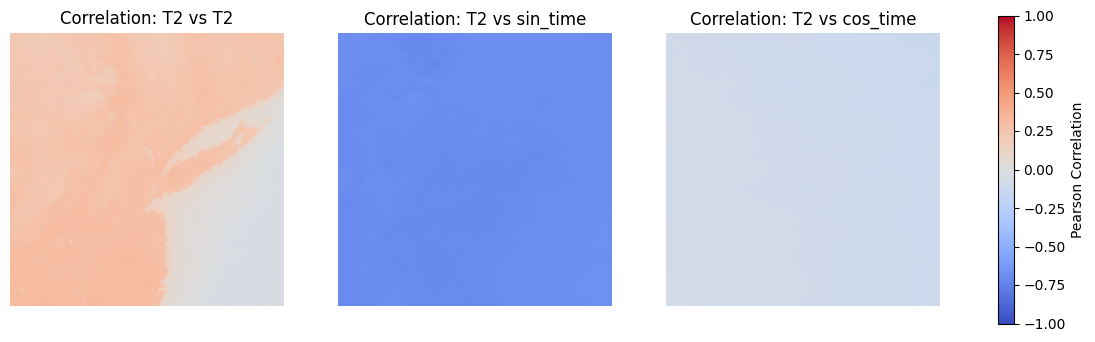

In [10]:
import matplotlib.pyplot as plt
n = len(corr_maps)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

for i, (name, cmap) in enumerate(corr_maps.items()):
    ax = axes[i]
    im = ax.imshow(cmap, vmin=-1, vmax=1, cmap='coolwarm', origin='lower')
    ax.set_title(f'Correlation: T2 vs {name}')
    ax.axis('off')

# Add a shared colorbar
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='Pearson Correlation')

plt.show()


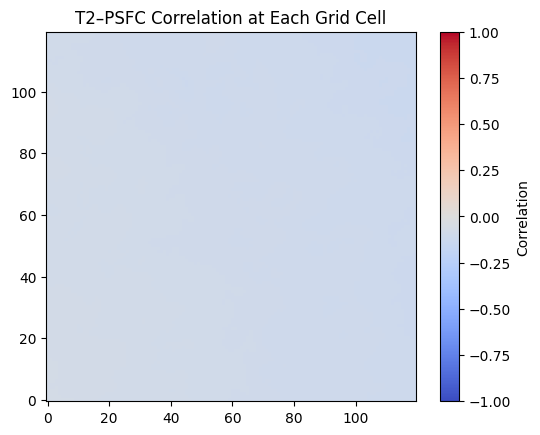

In [11]:
plt.imshow(corr_map, cmap='coolwarm', vmin=-1, vmax=1, origin='lower')
plt.colorbar(label='Correlation')
plt.title('T2–PSFC Correlation at Each Grid Cell')
plt.show()


# Linear Regression

In [12]:
t2 = data['T2'].values.flatten()
u10 = data

Intercept for SWDOWN vs T2: 272.377
Coefficient for SWDOWN vs T2: 0.007



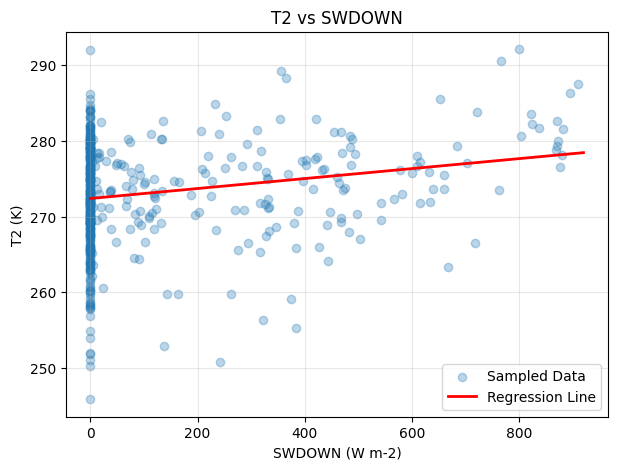

Intercept for SWDOWN vs sin_time: 0.335
Coefficient for SWDOWN vs sin_time: -0.002



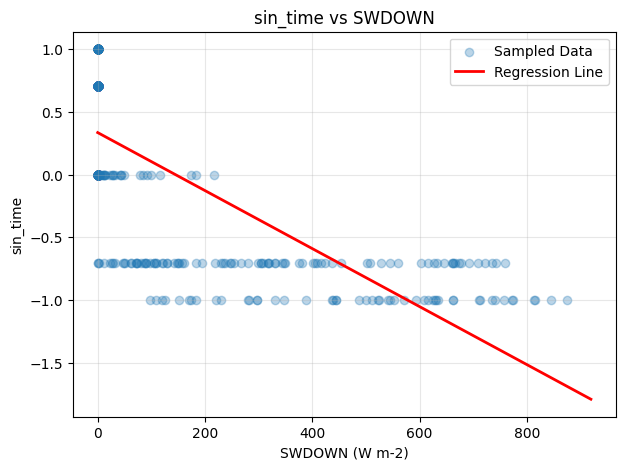

Intercept for SWDOWN vs cos_time: 0.039
Coefficient for SWDOWN vs cos_time: -0.000



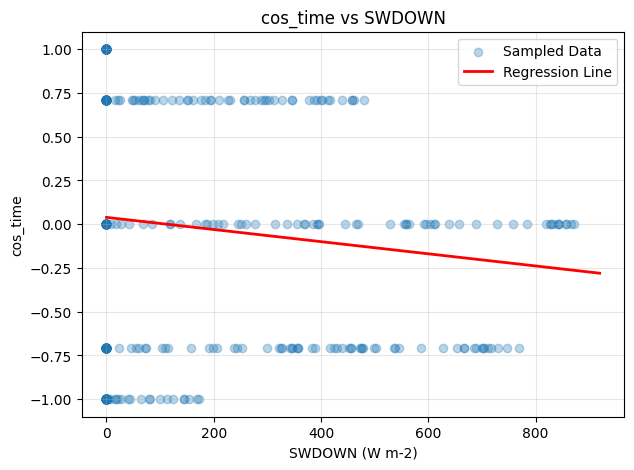

In [13]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

sample_size = 500 

for i in other_vars:
    # Flatten variables
    x = ds.values.flatten().reshape(-1, 1)  # Independent (e.g., T2)
    y = data[i].values.flatten()                 # Dependent (e.g., PSFC)

    # Remove NaNs
    mask = ~np.isnan(x.flatten()) & ~np.isnan(y)
    x = x[mask].reshape(-1, 1)
    y = y[mask]

    x_units = data[var].attrs.get('units', '')  # returns '' if no 'units' attribute
    y_units = data[i].attrs.get('units', '')

    # Fit regression on full data
    model = LinearRegression()
    model.fit(x, y)

    print(f'Intercept for {var} vs {i}: {model.intercept_:.3f}')
    print(f'Coefficient for {var} vs {i}: {model.coef_[0]:.3f}\n')

    # Regression line
    x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_pred = model.predict(x_range)

    # Random sample for plotting
    idx = np.random.choice(len(x), size=sample_size, replace=False)
    x_sample = x[idx]
    y_sample = y[idx]

    # Plot sampled points
    plt.figure(figsize=(7, 5))
    plt.scatter(x_sample, y_sample, alpha=0.3, label='Sampled Data')
    plt.plot(x_range, y_pred, color='red', linewidth=2, label='Regression Line')
    #plt.xlabel(f'{var} ({if data[var].units then data[var].units else pass})')
    #plt.ylabel(f'{i} ({data[i].units})')
    plt.xlabel(f"{var}" + (f" ({x_units})" if x_units else ""))
    plt.ylabel(f"{i}" + (f" ({y_units})" if y_units else ""))
    plt.title(f'{i} vs {var}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# Multiple Linear Regression

For meterological variables, it is more likely that there is an multivariate relationship than just one linear relationship. Since we are adding multiple predictors to our downscaling model, we would like to examine the relationship between the selection of predictor variables and the downscaling variable of interest.

===== Regression for SWDOWN =====
Intercept: -681.946
Coefficient for T2: 2.958
Coefficient for sin_time: -203.226
Coefficient for cos_time: -31.635
R^2 Score: 0.500



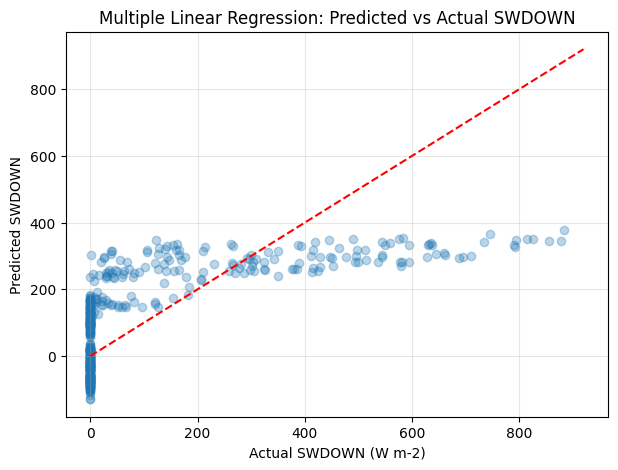

In [14]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

sample_size = 500  

# Flatten the target variable (var)
y = ds.values.flatten()  # target (e.g., T2)

# Stack predictors from other_vars
X = np.column_stack([data[p].values.flatten() for p in other_vars])

# Remove NaNs
mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
X = X[mask]
y = y[mask]

x_units = data[var].attrs.get('units', '')  # returns '' if no 'units' attribute
y_units = data[i].attrs.get('units', '')

# Fit multiple linear regression
model = LinearRegression()
model.fit(X, y)

print(f'===== Regression for {var} =====')
print(f'Intercept: {model.intercept_:.3f}')
for p, coef in zip(other_vars, model.coef_):
    print(f'Coefficient for {p}: {coef:.3f}')
print(f'R^2 Score: {model.score(X, y):.3f}\n')

# Predicted vs Actual Plot (sampled)
y_pred = model.predict(X)
idx = np.random.choice(len(y), size=sample_size, replace=False)

plt.figure(figsize=(7, 5))
plt.scatter(y[idx], y_pred[idx], alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 reference line
plt.xlabel(f'Actual {var} ({data[var].units})')
plt.xlabel(f"Actual {var}" + (f" ({x_units})" if x_units else ""))
plt.ylabel(f'Predicted {var}')
plt.title(f'Multiple Linear Regression: Predicted vs Actual {var}')
plt.grid(alpha=0.3)
plt.show()
